Plantas do Brasil:

**Fonte:** [GBIF — Global Biodiversity Information Facility](https://www.gbif.org/)  
**Escopo:** Registros de ocorrência de plantas com flor nativas do Brasil, com coordenadas geográficas validadas.

Analise em duas partes:

- **EDA** — distribuicao por especie, estado e linha do tempo de registros  
- **Clustering K-Means** — agrupamento geografico das ocorrencias, com selecao automatica do K via Silhouette Score

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
import os

warnings.filterwarnings("ignore")

In [2]:
# Cores extraidas do tema escuro do portfolio 
PORTFOLIO = {
    "bg":      "#071a0e",
    "bg2":     "#0c2214",
    "card":    "#0f2918",
    "border":  "#2a6642",
    "accent":  "#5ecf8a",
    "accent2": "#3aad6a",
    "accent3": "#a8edca",
    "text":    "#d6f5e3",
    "muted":   "#7bbf9a",
    "link":    "#7de8ac",
}

# Paleta sequencial para os graficos
PALETA = [
    "#5ecf8a", 
    "#00e5ff",  
    "#38ef7d", 
    "#70a1ff", 
    "#b388ff",  
    "#ff007f",  
    "#ff7675",  
    "#ffeaa7",  
    "#00cec9", 
    "#df80ff",  
]

plt.rcParams.update({
    "figure.facecolor":  PORTFOLIO["bg"],
    "axes.facecolor":    PORTFOLIO["bg2"],
    "axes.edgecolor":    PORTFOLIO["border"],
    "axes.labelcolor":   PORTFOLIO["text"],
    "xtick.color":       PORTFOLIO["muted"],
    "ytick.color":       PORTFOLIO["muted"],
    "text.color":        PORTFOLIO["text"],
    "grid.color":        PORTFOLIO["border"],
    "grid.linestyle":    "--",
    "grid.alpha":        0.4,
    "font.family":       "monospace",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "legend.facecolor":  PORTFOLIO["card"],
    "legend.edgecolor":  PORTFOLIO["border"],
    "legend.labelcolor": PORTFOLIO["text"],
})

### 1. Carregamento dos Dados

Leitura do parquet gerado na Etapa 1

In [3]:
df = pd.read_parquet("dados/plantas_brasil.parquet")

print(f"Shape: {df.shape[0]:,} linhas x {df.shape[1]} colunas")
print(f"Colunas: {list(df.columns)}")
df.head()

Shape: 8,348 linhas x 13 colunas
Colunas: ['especie', 'familia', 'genero', 'reino', 'latitude', 'longitude', 'estado', 'municipio', 'ano', 'mes', 'tipo_registro', 'dataset', 'id_gbif']


,especie,familia,genero,reino,latitude,longitude,estado,municipio,ano,mes,tipo_registro,dataset,id_gbif
0,Zeyheria Tuberculosa,Bignoniaceae,Zeyheria,Plantae,-22.887250,-48.490417,São Paulo,Botucatu,2026,1,PRESERVED_SPECIMEN,NaN,3414152432
1,Mauritia Flexuosa,Arecaceae,Mauritia,Plantae,-2.704655,-42.872883,Maranhão,NaN,2026,1,HUMAN_OBSERVATION,iNaturalist research-grade observations,5938027332
2,Microgramma Squamulosa,Polypodiaceae,Microgramma,Plantae,-28.046272,-49.519303,Santa Catarina,NaN,2026,1,HUMAN_OBSERVATION,iNaturalist research-grade observations,5938029900
3,Passiflora Capsularis,Passifloraceae,Passiflora,Plantae,-23.208287,-46.966167,São Paulo,NaN,2026,1,HUMAN_OBSERVATION,iNaturalist research-grade observations,5938032403
4,Passiflora Miersii,Passifloraceae,Passiflora,Plantae,-21.769328,-46.579995,Minas Gerais,NaN,2026,1,HUMAN_OBSERVATION,iNaturalist research-grade observations,5938032781


In [4]:
# Visao rapida de nulos e tipos
print("Tipos e nulos por coluna:\n")
info = pd.DataFrame({
    "dtype":  df.dtypes,
    "nulos":  df.isnull().sum(),
    "% nulo": (df.isnull().mean() * 100).round(1),
})
print(info.to_string())

Tipos e nulos por coluna:

                 dtype  nulos  % nulo
especie            str      0     0.0
familia            str      1     0.0
genero             str      0     0.0
reino              str      0     0.0
latitude       float64      0     0.0
longitude      float64      0     0.0
estado             str      0     0.0
municipio          str   7265    87.0
ano              Int64      0     0.0
mes              Int64      0     0.0
tipo_registro      str      0     0.0
dataset            str    943    11.3
id_gbif            str      0     0.0


### 2. Analise Exploratoria (EDA)

Tres perspectivas sobre o dataset:

1. Quais especies aparecem mais?
2. Como os registros se distribuem por estado?
3. Qual é a origem dos dados de biodiversidade?

**2.1** Top 10 Especies Mais Registradas

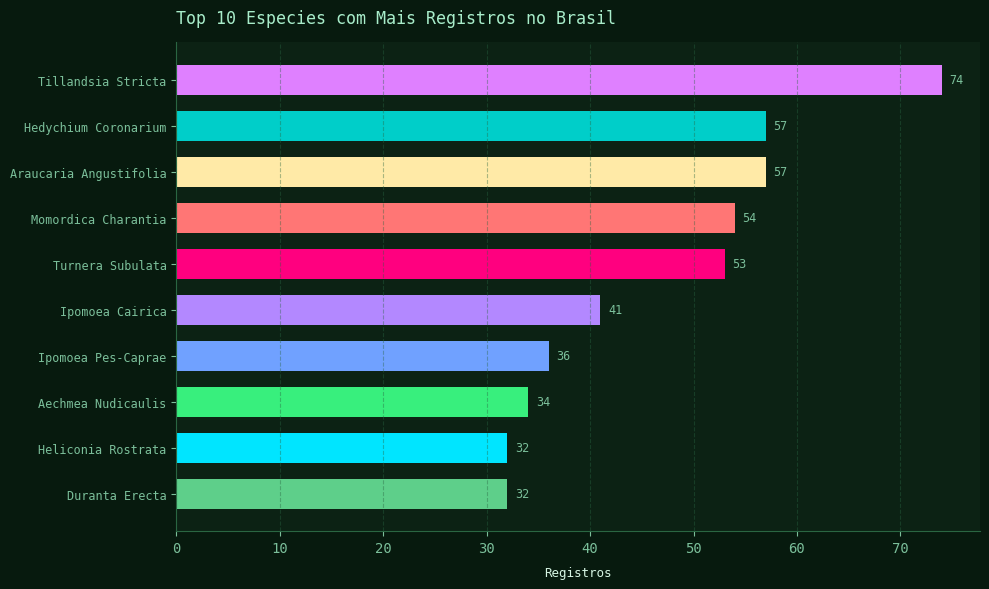

In [5]:
top10 = df["especie"].value_counts().head(10).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(top10.index, top10.values, color=PALETA[:10], edgecolor="none", height=0.65)

for bar, val in zip(bars, top10.values):
    ax.text(
        val + max(top10.values) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{val:,}",
        va="center", fontsize=8.5, color=PORTFOLIO["muted"]
    )

ax.set_title("Top 10 Especies com Mais Registros no Brasil",
             fontsize=12, pad=14, color=PORTFOLIO["accent3"], loc="left")
ax.set_xlabel("Registros", fontsize=9, labelpad=8)
ax.tick_params(axis="y", labelsize=8.5)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.grid(axis="x")

plt.tight_layout()
plt.show()

**2.2** Top 10 Estados com Mais Registros

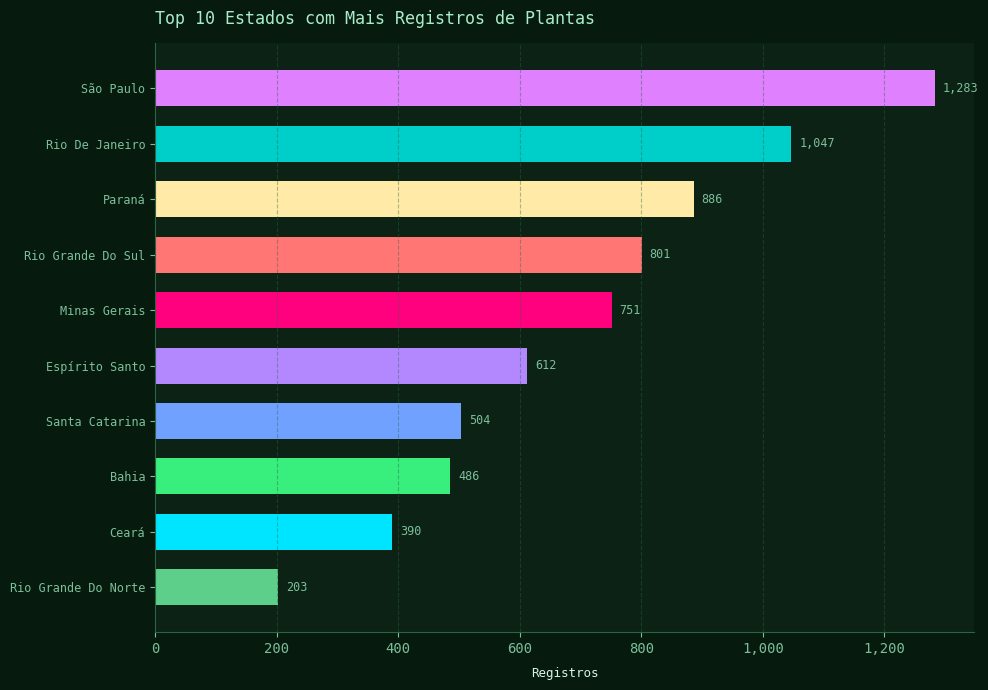

In [6]:
if "estado" not in df.columns:
    print("Coluna 'estado' nao encontrada.")
else:
    por_estado = (
        df["estado"]
        .value_counts()
        .dropna()
        .head(10)
        .sort_values(ascending=True)
    )

    fig, ax = plt.subplots(figsize=(10, 7))

    cores = [PALETA[i % len(PALETA)] for i in range(len(por_estado))]
    bars = ax.barh(por_estado.index, por_estado.values, color=cores, edgecolor="none", height=0.65)

    for bar, val in zip(bars, por_estado.values):
        ax.text(
            val + max(por_estado.values) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{val:,}",
            va="center", fontsize=8.5, color=PORTFOLIO["muted"]
        )

    ax.set_title("Top 10 Estados com Mais Registros de Plantas",
                 fontsize=12, pad=14, color=PORTFOLIO["accent3"], loc="left")
    ax.set_xlabel("Registros", fontsize=9, labelpad=8)
    ax.tick_params(axis="y", labelsize=8.5)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.grid(axis="x")

    plt.tight_layout()
    plt.show()

**2.3** Distribuicao por Tipo de Fonte

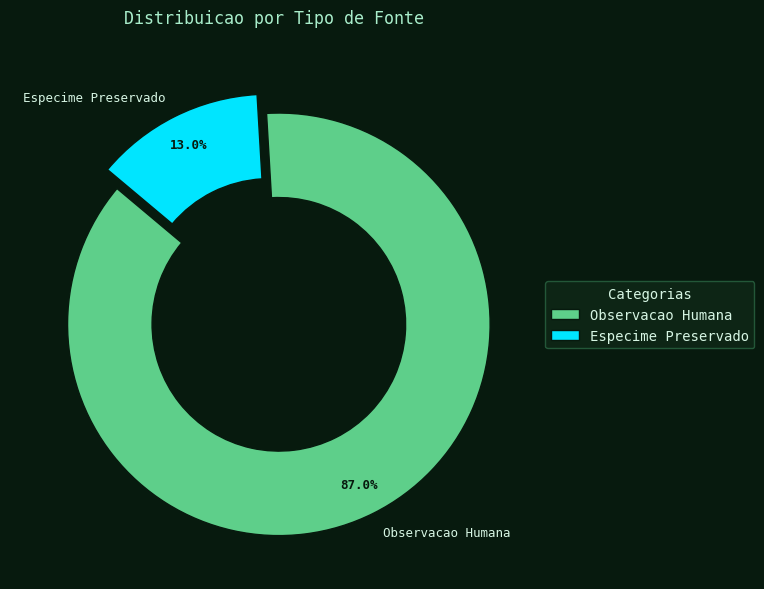

In [7]:
if "tipo_registro" not in df.columns:
    print("Coluna 'tipo_registro' nao encontrada.")
else:
    DIC_TRADUCAO = {
        "HUMAN_OBSERVATION": "Observacao Humana",
        "PRESERVED_SPECIMEN": "Especime Preservado"
    }
    
    tipo_traduzido = df["tipo_registro"].map(DIC_TRADUCAO).fillna(df["tipo_registro"])
    
    por_tipo = (
        tipo_traduzido
        .value_counts()
        .dropna()
    )
    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    cores = [PALETA[i % len(PALETA)] for i in range(len(por_tipo))]
    
    wedges, texts, autotexts = ax.pie(
        por_tipo.values, 
        labels=por_tipo.index, 
        autopct='%1.1f%%', 
        startangle=140,
        colors=cores,
        pctdistance=0.85,
        explode=[0.05] * len(por_tipo),
        textprops={'color': PORTFOLIO["text"], 'fontsize': 9},
        wedgeprops={'width': 0.4, 'edgecolor': PORTFOLIO["bg"]}
    )

    for autotext in autotexts:
        autotext.set_color(PORTFOLIO["bg"])
        autotext.set_weight('bold')

    ax.set_title("Distribuicao por Tipo de Fonte", 
                 fontsize=12, pad=20, color=PORTFOLIO["accent3"], loc="center")

    ax.legend(wedges, por_tipo.index,
              title="Categorias",
              loc="center left",
              bbox_to_anchor=(1, 0, 0.5, 1),
              facecolor=PORTFOLIO["card"],
              edgecolor=PORTFOLIO["border"],
              labelcolor=PORTFOLIO["text"])

    plt.tight_layout()
    plt.show()

### 3. Clustering K-Means

O objetivo e agrupar as ocorrencias por coordenada geografica, identificando regioes
com perfis similares de biodiversidade sem rotulos pre-definidos.

**Features:** `latitude` e `longitude` normalizadas com `StandardScaler`  
**K ideal:** selecionado automaticamente pelo maior Silhouette Score

**3.1** Preparacao das Features

In [8]:
df_geo = df.dropna(subset=["latitude", "longitude"]).copy()
print(f"Registros com coordenadas validas: {len(df_geo):,}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_geo[["latitude", "longitude"]])
print(f"Shape apos normalizacao: {X_scaled.shape}")

Registros com coordenadas validas: 8,348
Shape apos normalizacao: (8348, 2)


**3.2** Selecao do K — Metodo do Cotovelo e Silhouette Score

Dois criterios avaliados em conjunto:

- **Inercia (cotovelo):** queda na variancia intra-cluster (quanto menor, mais concentrado)
- **Silhouette Score:** mede a separacao entre clusters (0–1, quanto maior melhor)

In [9]:
def encontrar_k_ideal():
    K_MIN, K_MAX = 2, 8

    inercias     = []
    silhouettes  = []
    ks           = range(K_MIN, K_MAX + 1)

    print(f"Testando K de {K_MIN} a {K_MAX}...\n")
    print(f"{'K':>3}  {'Inercia':>12}  {'Silhouette':>12}")

    for k in ks:
        km  = KMeans(n_clusters=k, random_state=42, n_init=10)
        km.fit(X_scaled)
        sil = silhouette_score(X_scaled, km.labels_)
        inercias.append(km.inertia_)
        silhouettes.append(sil)
        print(f"{k:>3}  {km.inertia_:>12,.0f}  {sil:>12.4f}")

    ks_arr = np.array(list(ks))
    inercias_arr = np.array(inercias)
    silhouettes_arr = np.array(silhouettes)

    # Normaliza cotovelo (1 é o melhor/menor e 0 o pior/maior)
    inercia_norm = 1 - (inercias_arr - inercias_arr.min()) / (inercias_arr.max() - inercias_arr.min())

    # Normaliza silhouette (1 é o melhor/maior e 0 o pior/menor)
    sil_norm = (silhouettes_arr - silhouettes_arr.min()) / (silhouettes_arr.max() - silhouettes_arr.min())

    score_composto = (0.5 * inercia_norm) + (0.5 * sil_norm)

    idx_ideal = np.argmax(score_composto)
    k_ideal = int(ks_arr[idx_ideal])

    print(f"\n K ideal pelo criterio de equilibrio: {k_ideal}")

    return k_ideal, ks, inercias, silhouettes

k_ideal, ks, inercias, silhouettes = encontrar_k_ideal()

Testando K de 2 a 8...

  K       Inercia    Silhouette
  2         8,658        0.5401
  3         5,587        0.4743
  4         3,263        0.5104
  5         2,624        0.5259
  6         2,112        0.4471
  7         1,675        0.4740
  8         1,406        0.4822

 K ideal pelo criterio de equilibrio: 5


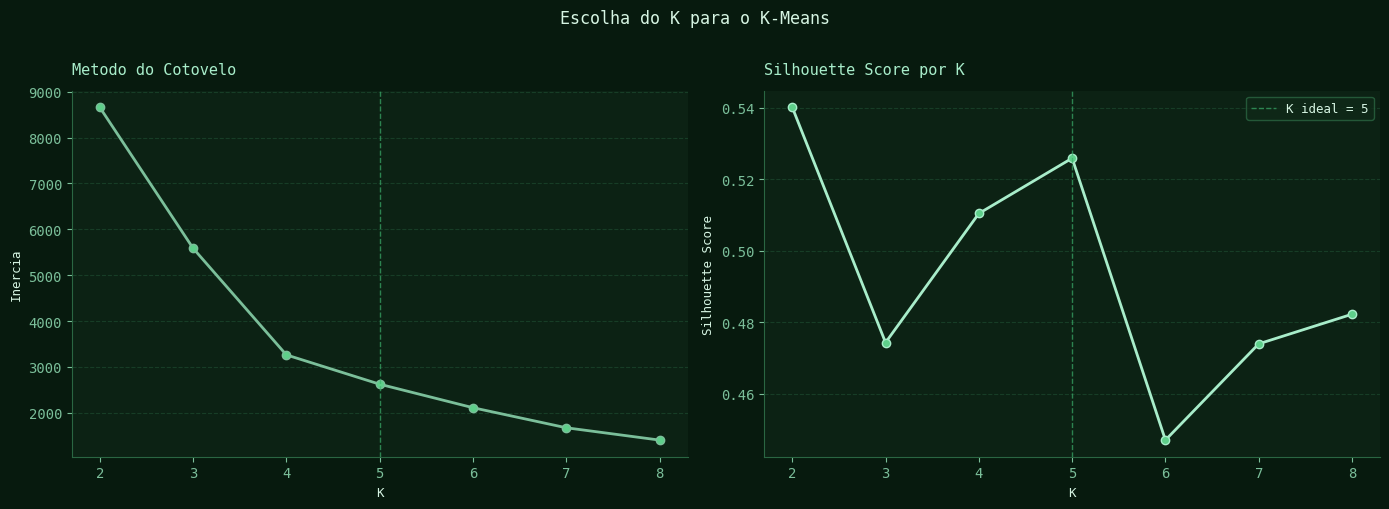

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Cotovelo
ax1.plot(list(ks), inercias,
         color=PORTFOLIO["muted"], linewidth=2,
         marker="o", markersize=6, markerfacecolor=PORTFOLIO["accent"])
ax1.axvline(k_ideal, color=PORTFOLIO["accent2"], linestyle="--", linewidth=1, alpha=0.7)
ax1.set_title("Metodo do Cotovelo",
              fontsize=11, pad=12, color=PORTFOLIO["accent3"], loc="left")
ax1.set_xlabel("K", fontsize=9)
ax1.set_ylabel("Inercia", fontsize=9)
ax1.grid(axis="y")

# Silhouette
ax2.plot(list(ks), silhouettes,
         color=PORTFOLIO["accent3"], linewidth=2,
         marker="o", markersize=6, markerfacecolor=PORTFOLIO["accent"])
ax2.axvline(k_ideal, color=PORTFOLIO["accent2"], linestyle="--", linewidth=1, alpha=0.7,
            label=f"K ideal = {k_ideal}")
ax2.set_title("Silhouette Score por K",
              fontsize=11, pad=12, color=PORTFOLIO["accent3"], loc="left")
ax2.set_xlabel("K", fontsize=9)
ax2.set_ylabel("Silhouette Score", fontsize=9)
ax2.legend(fontsize=9)
ax2.grid(axis="y")

fig.suptitle("Escolha do K para o K-Means",
             fontsize=12, color=PORTFOLIO["text"], y=1.01)

plt.tight_layout()
plt.show()

**3.3** Treinamento com K Ideal

In [11]:
km_final = KMeans(n_clusters=k_ideal, random_state=42, n_init=10)
labels   = km_final.fit_predict(X_scaled)

df_geo = df_geo.copy()
df_geo["cluster"] = labels.astype(str)

print(f"K-Means treinado com K = {k_ideal}")
print("\nDistribuicao dos clusters:")
print(df_geo["cluster"].value_counts().sort_index().to_string())

K-Means treinado com K = 5

Distribuicao dos clusters:
cluster
0    2542
1    1442
2    3507
3     200
4     657


**3.4** Visualizacao Geografica dos Clusters

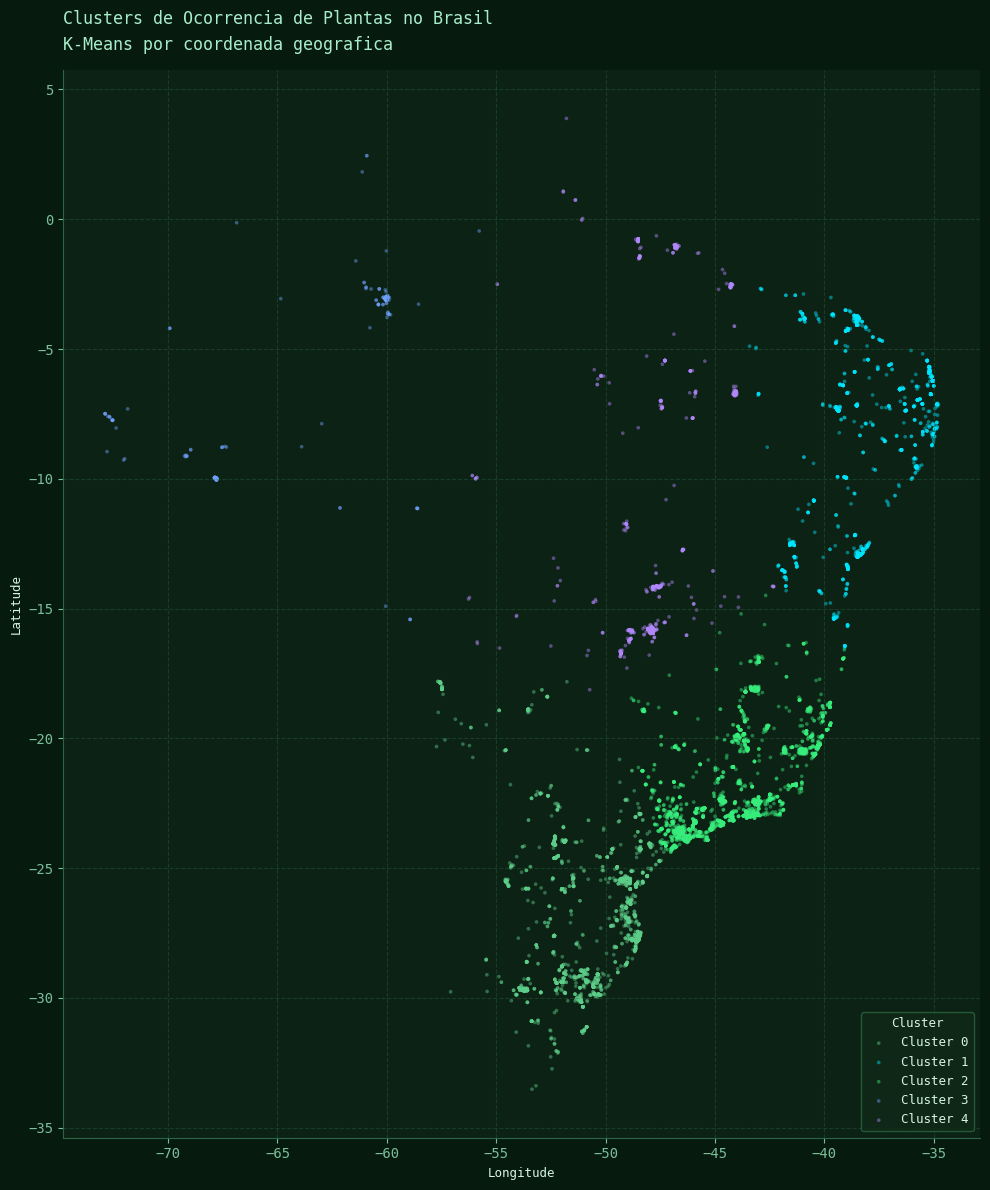

In [12]:
cores_cluster = {str(i): PALETA[i % len(PALETA)] for i in range(k_ideal)}

fig, ax = plt.subplots(figsize=(10, 12))

for cluster_id, grupo in df_geo.groupby("cluster"):
    ax.scatter(
        grupo["longitude"], grupo["latitude"],
        c=cores_cluster[cluster_id],
        label=f"Cluster {cluster_id}",
        alpha=0.45, s=7, edgecolors="none"
    )

ax.set_title(
    "Clusters de Ocorrencia de Plantas no Brasil\nK-Means por coordenada geografica",
    fontsize=12, pad=14, color=PORTFOLIO["accent3"], loc="left", linespacing=1.6
)
ax.set_xlabel("Longitude", fontsize=9)
ax.set_ylabel("Latitude", fontsize=9)
ax.legend(title="Cluster", loc="lower right", fontsize=9, title_fontsize=9)
ax.grid(True)

plt.tight_layout()
plt.show()

**3.5** Resumo por Cluster

Estatisticas agregadas por cluster: total de registros, especies unicas,
especie mais frequente, centroide geografico e estado com mais ocorrencias.

In [13]:
resumo = df_geo.groupby("cluster").agg(
    total_registros = ("especie", "count"),
    especies_unicas = ("especie", "nunique"),
    especie_top     = ("especie", lambda x: x.value_counts().idxmax()),
    lat_media       = ("latitude",  "mean"),
    lon_media       = ("longitude", "mean"),
).round(3)

if "estado" in df_geo.columns:
    estado_top = df_geo.groupby("cluster")["estado"].agg(
        lambda x: x.value_counts().idxmax() if x.notna().any() else "N/A"
    )
    resumo["estado_top"] = estado_top

resumo

,total_registros,especies_unicas,especie_top,lat_media,lon_media,estado_top
cluster,,,,,,
0,2542,1118,Araucaria Angustifolia,-26.488,-50.856,Paraná
1,1442,689,Turnera Subulata,-8.372,-38.022,Bahia
2,3507,1442,Tillandsia Stricta,-21.839,-43.993,São Paulo
3,200,150,Celtis Iguanaea,-6.423,-64.343,Amazonas
4,657,439,Qualea Grandiflora,-10.776,-47.712,Goiás


### 4. Conclusao

Ao observar o mapa, fica evidente que os agrupamentos encontrados pelo K-Means deram resultados. Mesmo utilizando apenas as coordenadas geográficas, o algoritmo conseguiu separar regiões que lembram bastante alguns dos principais padrões de biodiversidade do Brasil. O Sul apareceu concentrado no Cluster 0, onde a espécie mais representativa foi a Araucaria angustifolia, característica da Mata de Araucárias. No Norte, o Cluster 3 reuniu registros associados à Amazônia, enquanto o Cluster 1 agrupou grande parte do Nordeste, com espécies comuns da caatinga e do agreste aparecendo entre as mais frequentes.

Outro aspecto que chama atenção é a distribuição da quantidade de registros. O Cluster 2, concentrado principalmente no Sudeste e em São Paulo, reúne 350 observações, muito acima dos demais grupos. Esse resultado provavelmente reflete menos a biodiversidade da região e mais a forma como os dados são produzidos. Áreas com maior presença de universidades, pesquisadores e usuários de plataformas de ciência cidadã tendem a gerar mais registros, criando concentrações que também aparecem nos agrupamentos.

Por fim, o Cluster 4 destacou a região central do país e apresentou como espécie mais representativa a Qualea grandiflora (Pau-Terra), uma árvore bastante associada ao Cerrado. Esse resultado reforça como o algoritmo conseguiu identificar não apenas grandes divisões geográficas, mas também áreas com características ecológicas semelhantes. No conjunto, os clusters mostram que padrões naturais da vegetação brasileira emergem dos próprios dados, revelando relações que vão além da simples localização dos registros.
